# Notebook 07: Final Visualizations

Publication-quality figures that tell the story of market manipulation.
All charts use a consistent style and color scheme.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

COLORS = {
    'escalation': '#d62728',
    'de_escalation': '#2ca02c',
    'neutral': '#7f7f7f',
    'fabrication': '#ff7f0e',
    'oil_price': '#1f77b4',
    'djt': '#9467bd',
    'high': '#d62728',
    'elevated': '#ff7f0e',
    'low': '#2ca02c'
}

# Load final scored data
scores = pd.read_csv('../data/processed/manipulation_scores.csv')
scores['date'] = pd.to_datetime(scores['date'])

master = pd.read_csv('../data/processed/master_dataset.csv')
master['date'] = pd.to_datetime(master['date'])

posts = pd.read_csv('../data/processed/posts_cleaned.csv')
posts['timestamp'] = pd.to_datetime(posts['timestamp'])

gemini = pd.read_csv('../data/processed/gemini_classifications.csv')
gemini['date'] = pd.to_datetime(gemini['date'])

print('Data loaded for visualization.')

Data loaded for visualization.


## Figure 1: Hero Chart — Full Period Overview

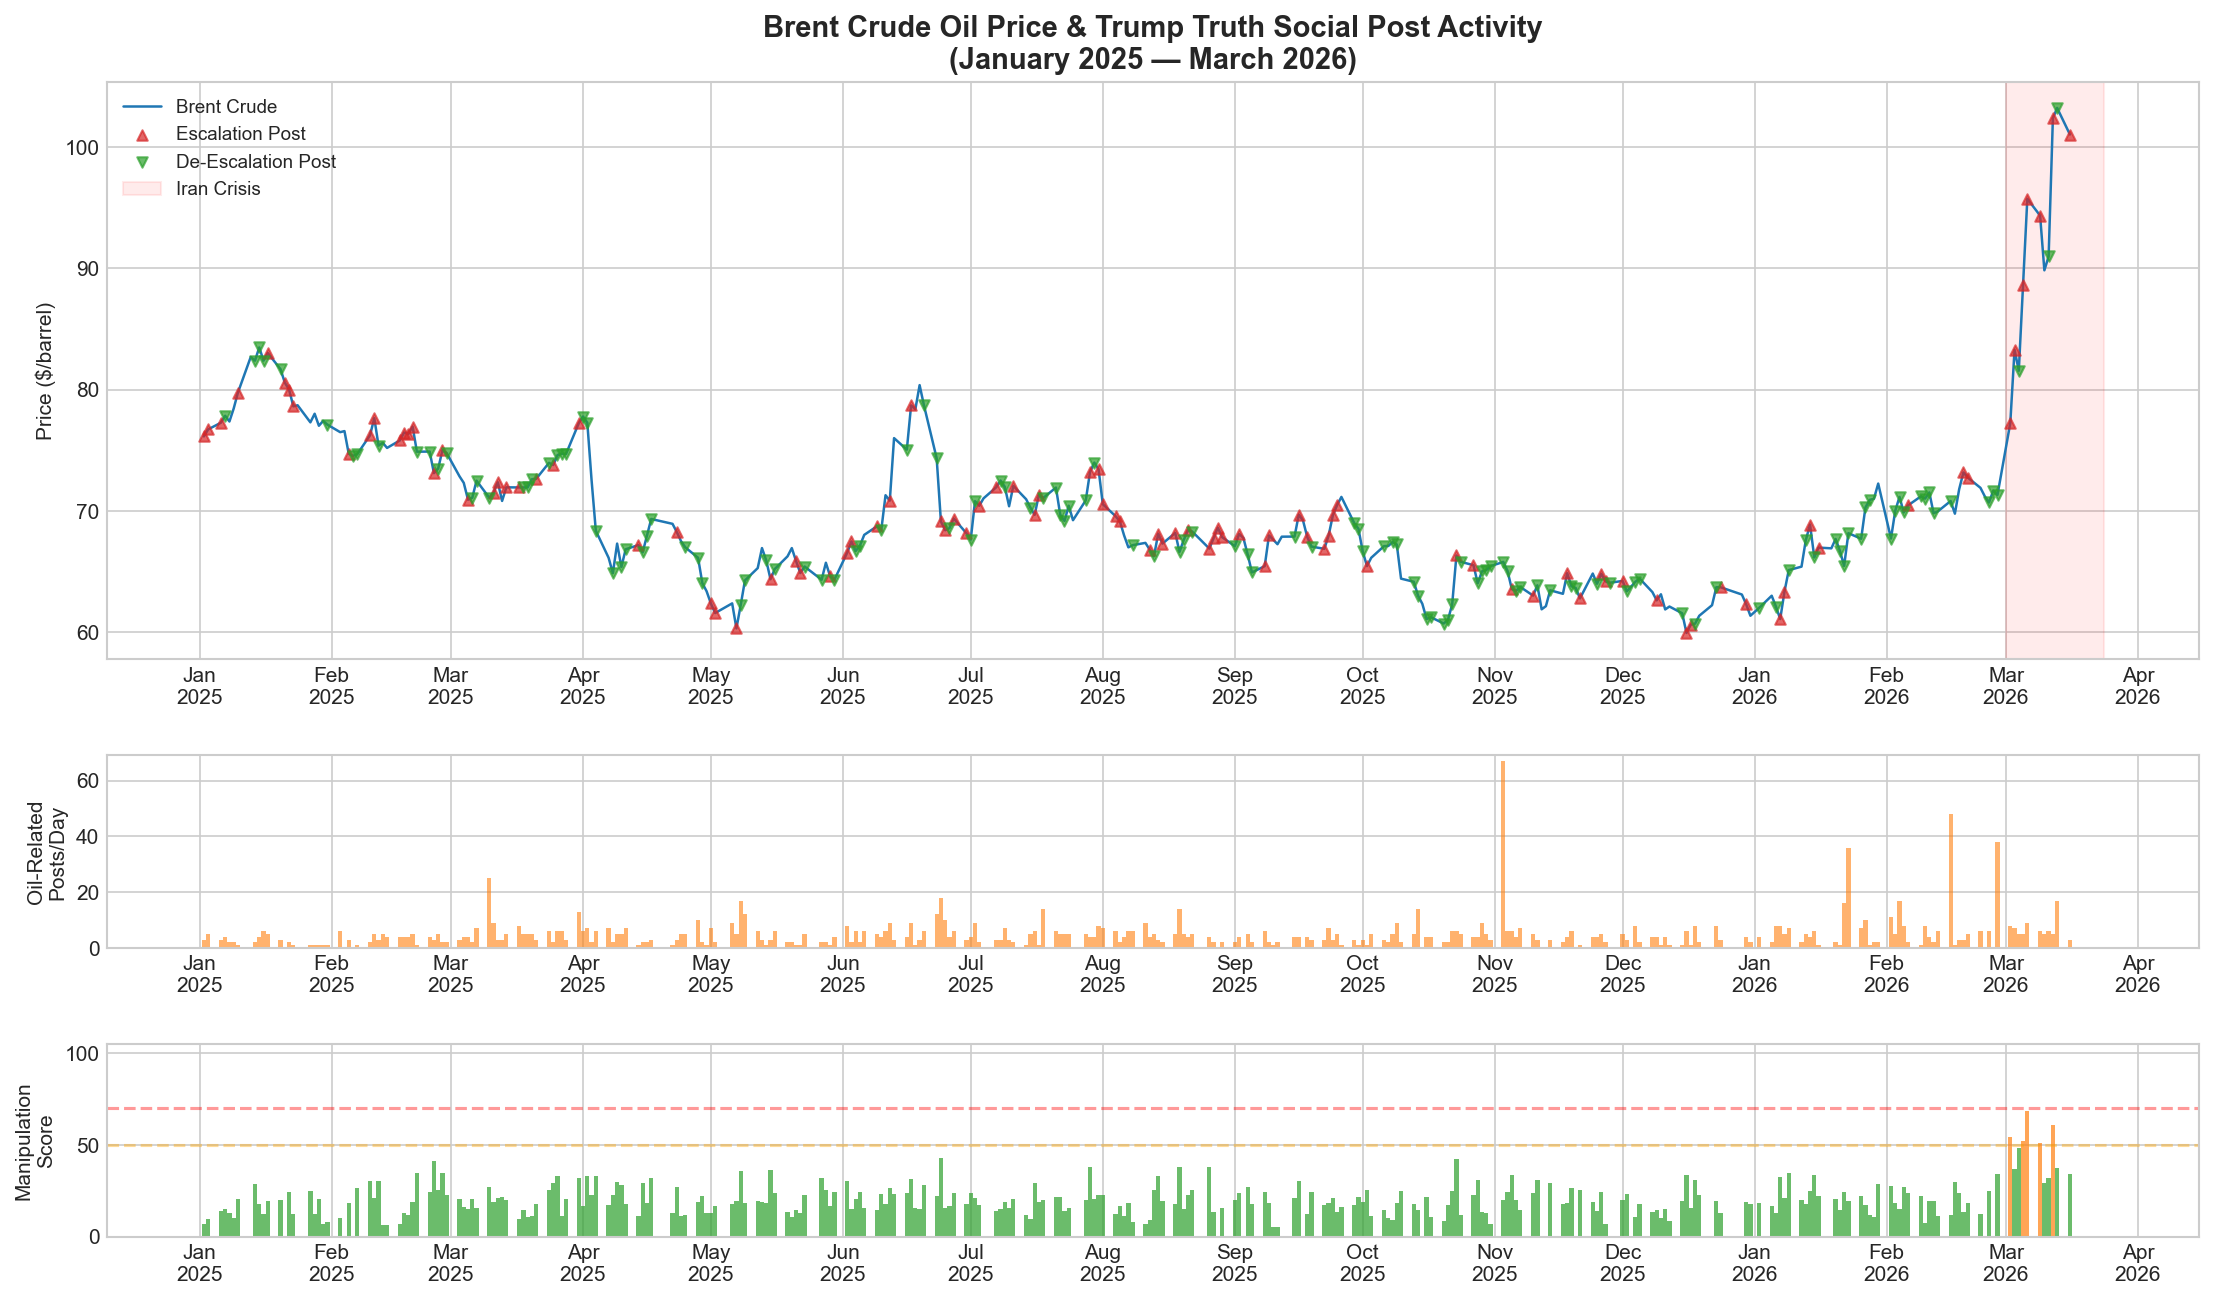

In [2]:
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.3)

# Top: Oil price with post markers
ax1 = fig.add_subplot(gs[0])
trading = scores[scores['brent_close'].notna()]

ax1.plot(trading['date'], trading['brent_close'], 
         color=COLORS['oil_price'], linewidth=1.2, label='Brent Crude', zorder=2)

# Color-coded markers for post days
for direction, color, marker in [
    ('escalation', COLORS['escalation'], '^'),
    ('de_escalation', COLORS['de_escalation'], 'v'),
]:
    mask = trading['dominant_direction'] == direction
    subset = trading[mask]
    if len(subset) > 0:
        ax1.scatter(subset['date'], subset['brent_close'], 
                    color=color, s=25, alpha=0.7, marker=marker,
                    label=f'{direction.replace("_", "-").title()} Post', zorder=3)

ax1.axvspan(pd.Timestamp('2026-03-01'), pd.Timestamp('2026-03-24'), 
            alpha=0.08, color='red', label='Iran Crisis')

ax1.set_title('Brent Crude Oil Price & Trump Truth Social Post Activity\n(January 2025 — March 2026)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($/barrel)')
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

# Middle: Daily post count
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(scores['date'], scores['oil_post_count'], 
        color=COLORS['fabrication'], alpha=0.6, width=1)
ax2.set_ylabel('Oil-Related\nPosts/Day')
ax2.set_ylim(0, scores['oil_post_count'].max() + 2)

# Bottom: Manipulation score
ax3 = fig.add_subplot(gs[2], sharex=ax1)
bar_colors = scores['verdict'].map({'HIGH': COLORS['high'], 
                                     'ELEVATED': COLORS['elevated'], 
                                     'LOW': COLORS['low']}).fillna('#cccccc')
ax3.bar(scores['date'], scores['manipulation_score'], 
        color=bar_colors, width=1, alpha=0.7)
ax3.axhline(y=70, color='red', linestyle='--', alpha=0.4)
ax3.axhline(y=50, color='orange', linestyle='--', alpha=0.4)
ax3.set_ylabel('Manipulation\nScore')
ax3.set_ylim(0, 105)

plt.savefig('../data/processed/fig_hero_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2: March 2026 Crisis — Annotated Timeline

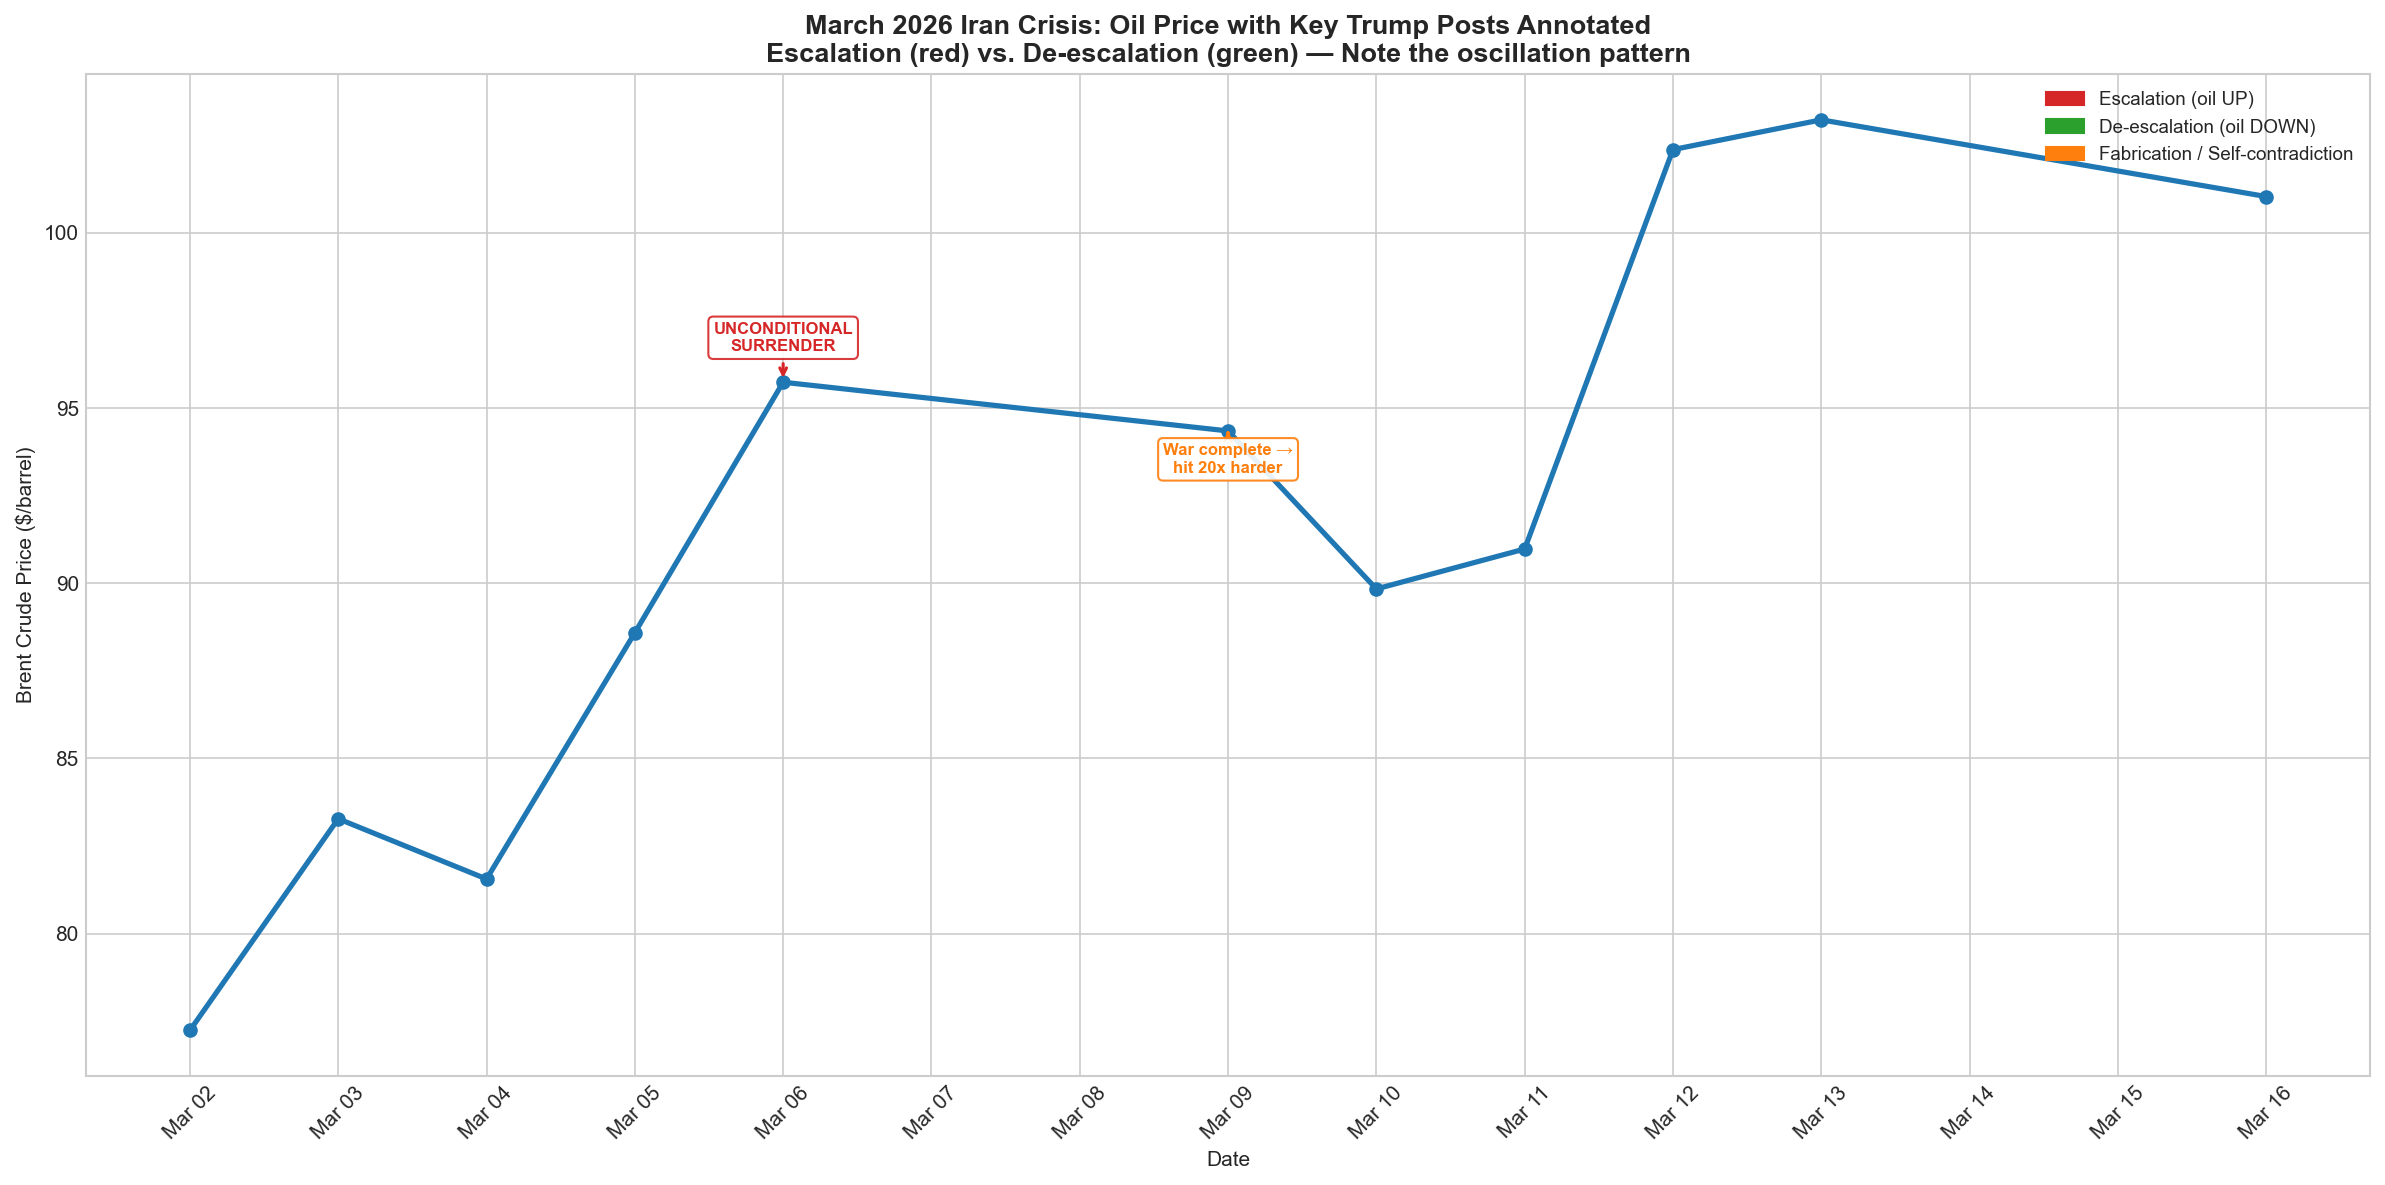

In [3]:
march = scores[(scores['date'] >= '2026-03-01') & (scores['date'] <= '2026-03-24')].copy()
march_trading = march[march['brent_close'].notna()]

# Key events to annotate
annotations = [
    ('2026-03-06', 'UNCONDITIONAL\nSURRENDER', 'escalation', 15),
    ('2026-03-09', 'War complete →\nhit 20x harder', 'fabrication', -20),
    ('2026-03-21', '48-hour\nultimatum', 'escalation', 15),
    ('2026-03-22', 'OBLITERATE', 'escalation', -25),
    ('2026-03-23', 'Productive talks\n(FABRICATED)', 'de_escalation', 20),
    ('2026-03-24', '5-day extension\n(backdown)', 'de_escalation', -20),
]

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(march_trading['date'], march_trading['brent_close'], 
        color=COLORS['oil_price'], linewidth=2.5, marker='o', markersize=6, zorder=2)

for date_str, label, direction, y_offset in annotations:
    date = pd.Timestamp(date_str)
    closest = march_trading.iloc[(march_trading['date'] - date).abs().argsort()[:1]]
    if len(closest) > 0:
        price = closest.iloc[0]['brent_close']
        if pd.notna(price):
            color = COLORS[direction]
            ax.annotate(
                label,
                xy=(date, price),
                xytext=(0, y_offset),
                textcoords='offset points',
                fontsize=8, fontweight='bold',
                color=color,
                ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor=color, alpha=0.9),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5)
            )

ax.set_title('March 2026 Iran Crisis: Oil Price with Key Trump Posts Annotated\n'
             'Escalation (red) vs. De-escalation (green) — Note the oscillation pattern', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Brent Crude Price ($/barrel)')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

# Add legend for direction colors
legend_elements = [
    mpatches.Patch(color=COLORS['escalation'], label='Escalation (oil UP)'),
    mpatches.Patch(color=COLORS['de_escalation'], label='De-escalation (oil DOWN)'),
    mpatches.Patch(color=COLORS['fabrication'], label='Fabrication / Self-contradiction'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_march_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3: Manipulation Score Dashboard

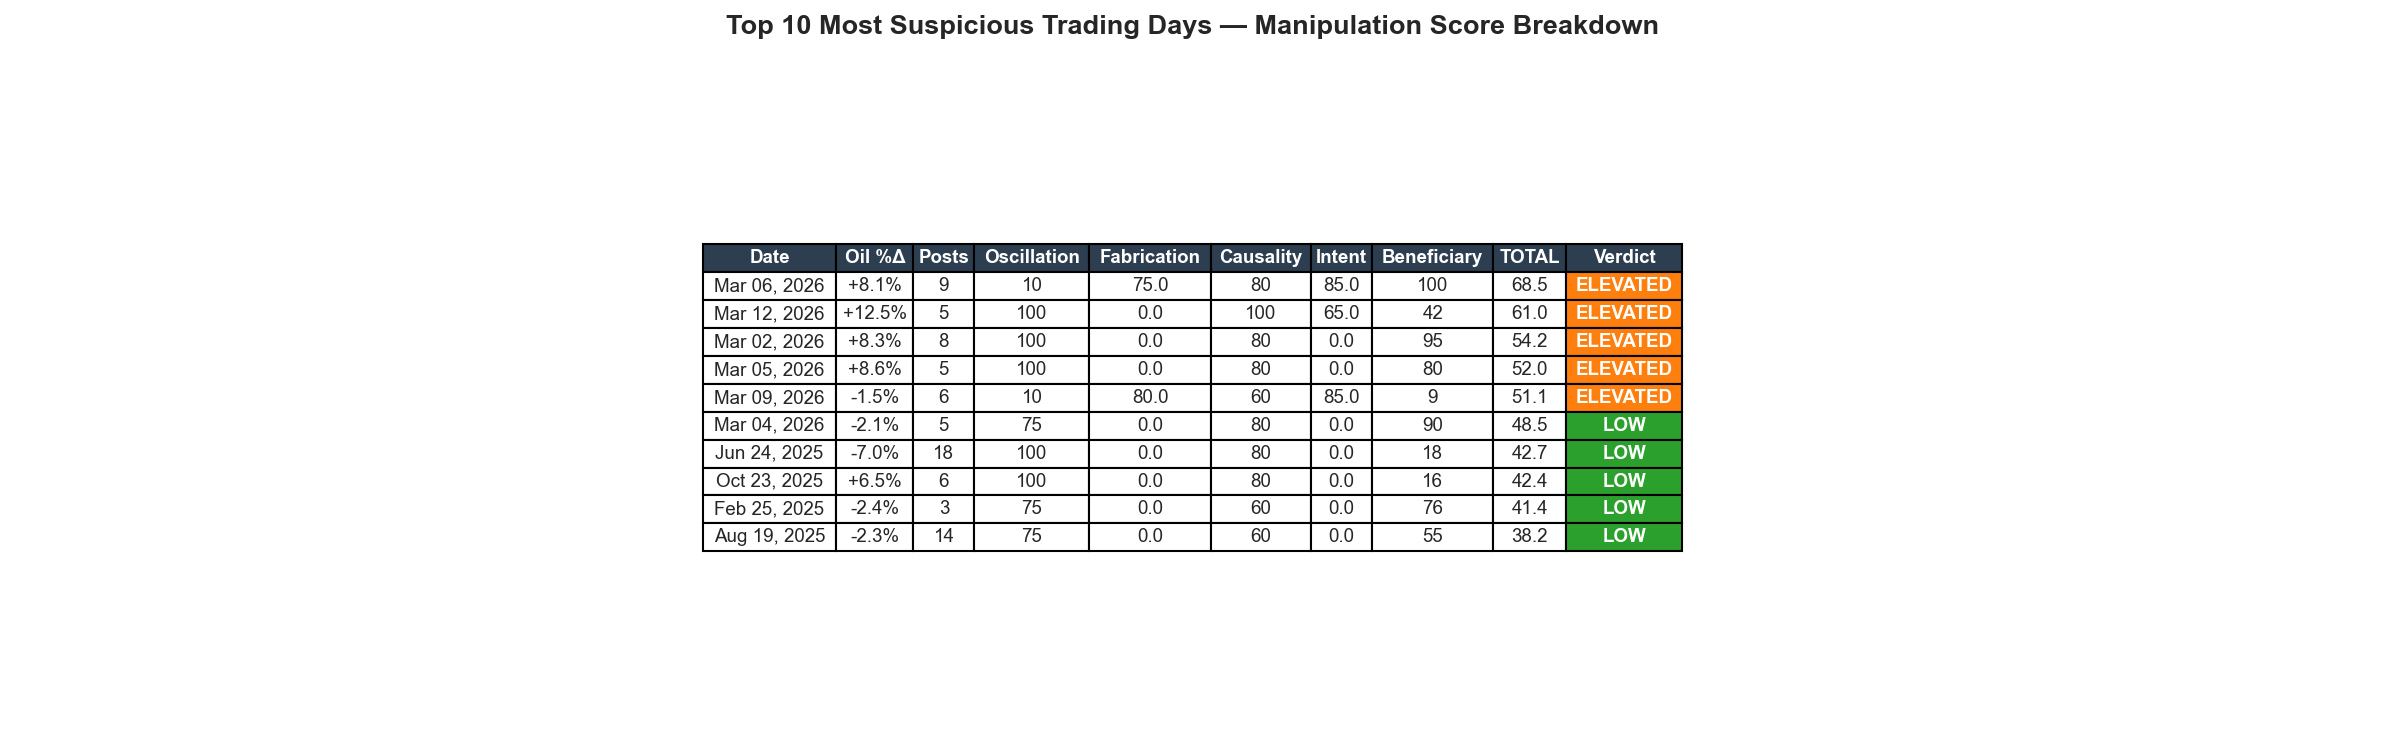

In [4]:
# Create summary evidence table
top_days = scores.nlargest(10, 'manipulation_score').copy()
top_days['date_str'] = top_days['date'].dt.strftime('%b %d, %Y')

display_cols = {
    'date_str': 'Date',
    'brent_pct_change': 'Oil %Δ',
    'oil_post_count': 'Posts',
    'oscillation_score': 'Oscillation',
    'fabrication_score': 'Fabrication',
    'causality_score': 'Causality',
    'intent_score': 'Intent',
    'beneficiary_score': 'Beneficiary',
    'manipulation_score': 'TOTAL',
    'verdict': 'Verdict'
}

available = {k: v for k, v in display_cols.items() if k in top_days.columns}
table_df = top_days[available.keys()].rename(columns=available)

# Format numbers
if 'Oil %Δ' in table_df.columns:
    table_df['Oil %Δ'] = table_df['Oil %Δ'].apply(lambda x: f'{x:+.1f}%' if pd.notna(x) else 'N/A')

fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('off')

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(table_df.columns))))

# Color code verdict cells
for i in range(len(table_df)):
    verdict = top_days.iloc[i]['verdict']
    color = COLORS.get(verdict.lower(), '#ffffff')
    verdict_col = list(available.values()).index('Verdict') if 'Verdict' in available.values() else -1
    if verdict_col >= 0:
        table[i + 1, verdict_col].set_facecolor(color)
        table[i + 1, verdict_col].set_text_props(color='white', fontweight='bold')

# Header styling
for j in range(len(table_df.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Top 10 Most Suspicious Trading Days — Manipulation Score Breakdown', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../data/processed/fig_evidence_table.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4: DJT vs. Oil Scatter Plot

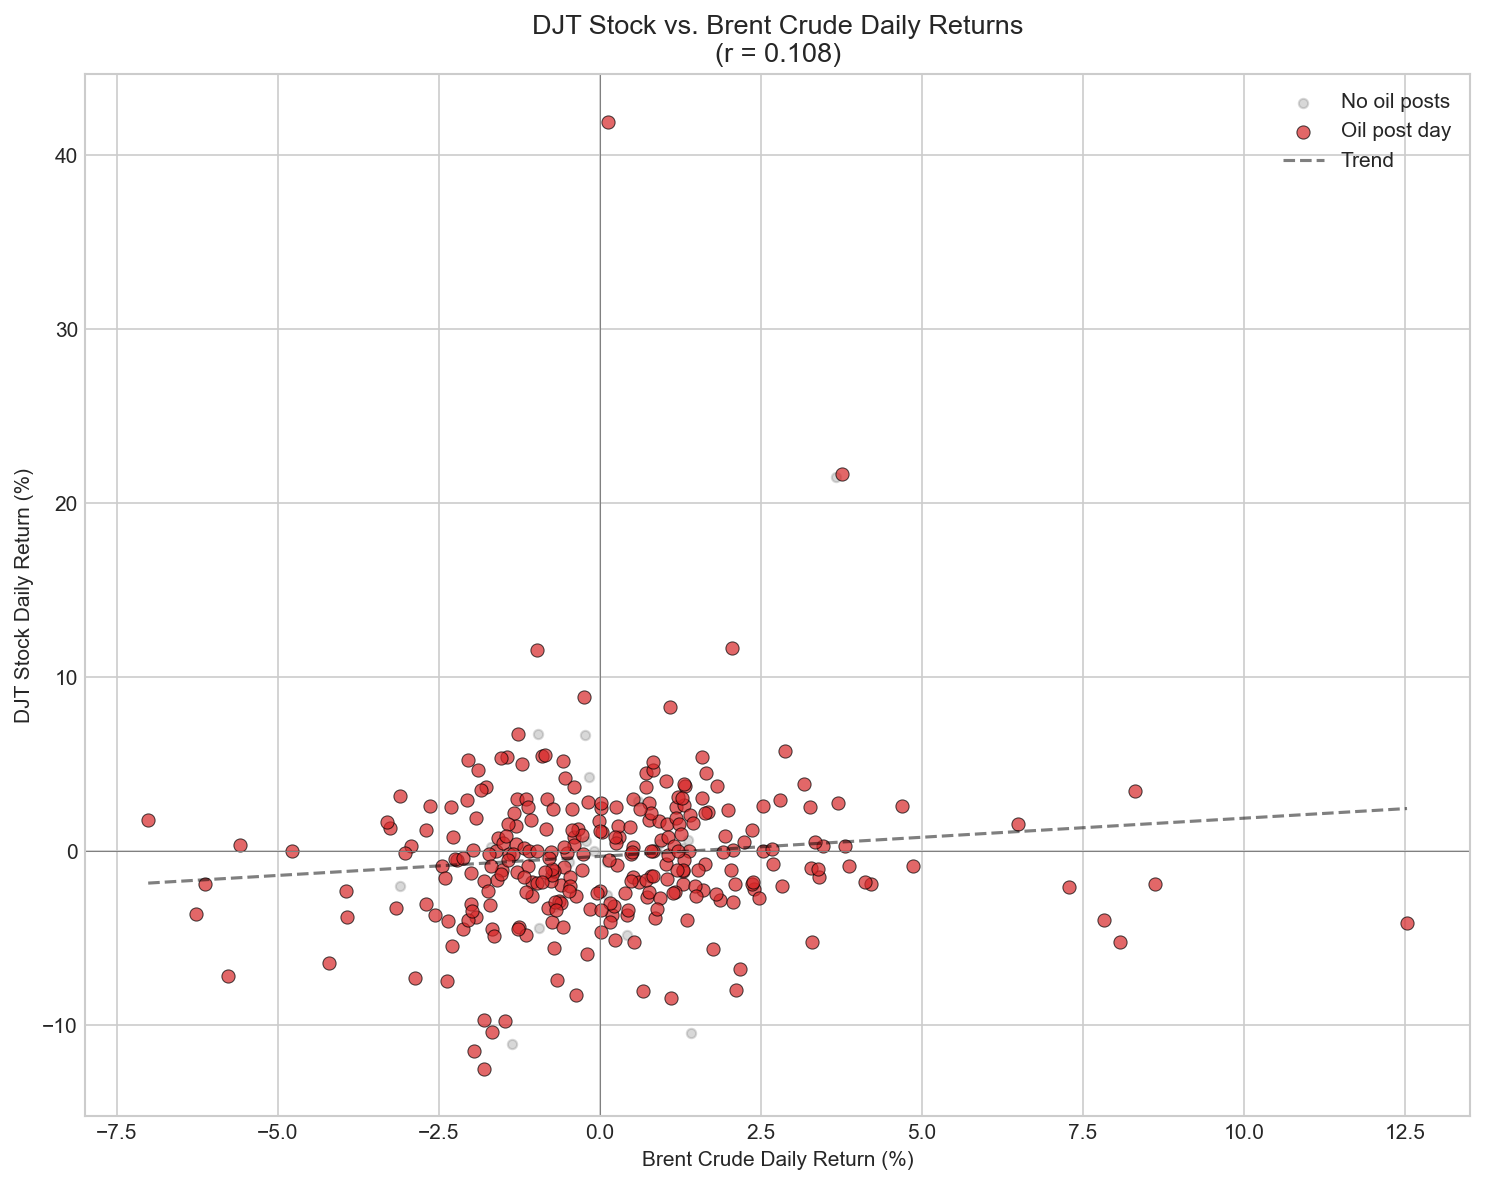

In [5]:
scatter_data = scores[scores['brent_pct_change'].notna() & scores['djt_pct_change'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 8))

# Color by post activity
no_posts = scatter_data[scatter_data['oil_post_count'] == 0]
with_posts = scatter_data[scatter_data['oil_post_count'] > 0]

ax.scatter(no_posts['brent_pct_change'], no_posts['djt_pct_change'],
           color=COLORS['neutral'], alpha=0.3, s=20, label='No oil posts')
ax.scatter(with_posts['brent_pct_change'], with_posts['djt_pct_change'],
           color=COLORS['escalation'], alpha=0.7, s=40, label='Oil post day', edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(scatter_data['brent_pct_change'].dropna(), 
               scatter_data['djt_pct_change'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_data['brent_pct_change'].min(), scatter_data['brent_pct_change'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linestyle='--', alpha=0.5, label='Trend')

corr = scatter_data['brent_pct_change'].corr(scatter_data['djt_pct_change'])
ax.set_title(f'DJT Stock vs. Brent Crude Daily Returns\n(r = {corr:.3f})', fontsize=13)
ax.set_xlabel('Brent Crude Daily Return (%)')
ax.set_ylabel('DJT Stock Daily Return (%)')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('../data/processed/fig_djt_vs_oil.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5: Manipulation Score Time Series

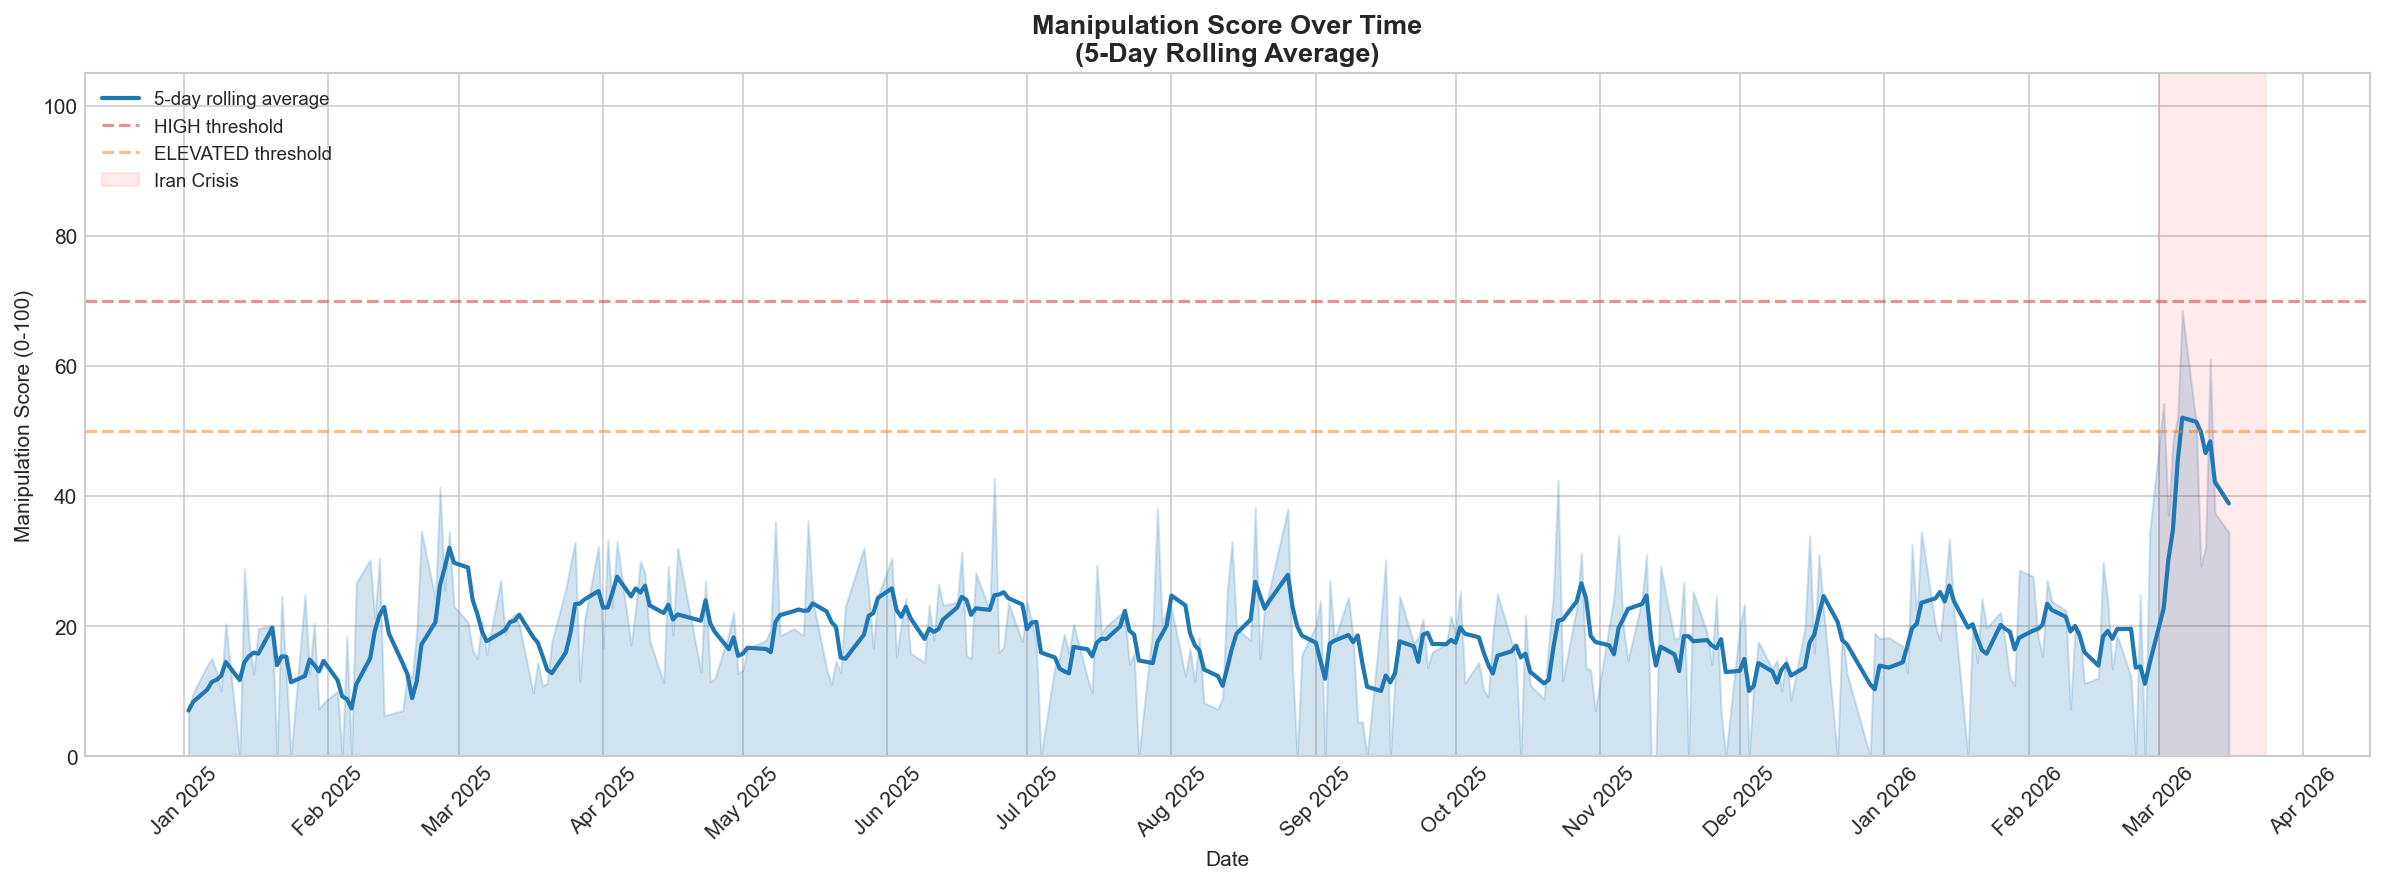

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

# Rolling 5-day average
scores_sorted = scores.sort_values('date')
scores_sorted['score_rolling'] = scores_sorted['manipulation_score'].rolling(5, min_periods=1).mean()

ax.fill_between(scores_sorted['date'], scores_sorted['manipulation_score'], 
                alpha=0.2, color=COLORS['oil_price'])
ax.plot(scores_sorted['date'], scores_sorted['score_rolling'], 
        color=COLORS['oil_price'], linewidth=2, label='5-day rolling average')

ax.axhline(y=70, color=COLORS['high'], linestyle='--', alpha=0.5, label='HIGH threshold')
ax.axhline(y=50, color=COLORS['elevated'], linestyle='--', alpha=0.5, label='ELEVATED threshold')

# Shade Iran crisis
ax.axvspan(pd.Timestamp('2026-03-01'), pd.Timestamp('2026-03-24'), 
            alpha=0.08, color='red', label='Iran Crisis')

ax.set_title('Manipulation Score Over Time\n(5-Day Rolling Average)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Manipulation Score (0-100)')
ax.set_ylim(0, 105)
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/fig_score_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print('=== ALL VISUALIZATIONS SAVED ===')
import os
for f in sorted(os.listdir('../data/processed')):
    if f.startswith('fig_'):
        size = os.path.getsize(f'../data/processed/{f}') / 1024
        print(f'  {f} ({size:.0f} KB)')

print('\nNext steps:')
print('  1. Run app.py for the interactive Streamlit dashboard')
print('  2. Write README.md')

=== ALL VISUALIZATIONS SAVED ===
  fig_correlation_heatmap.png (282 KB)
  fig_djt_vs_oil.png (105 KB)
  fig_evidence_table.png (99 KB)
  fig_fabrication_timeline.png (134 KB)
  fig_gemini_classification.png (110 KB)
  fig_hero_chart.png (189 KB)
  fig_intraday_causality.png (216 KB)
  fig_march_annotated.png (121 KB)
  fig_march_crisis_zoom.png (119 KB)
  fig_oil_price_timeline.png (210 KB)
  fig_score_decomposition.png (115 KB)
  fig_score_timeseries.png (231 KB)
  fig_volatility_comparison.png (64 KB)

Next steps:
  1. Run app.py for the interactive Streamlit dashboard
  2. Write README.md
